<a href="https://colab.research.google.com/github/Wolferlk/ML-Group-Project/blob/main/house-price-prediction-ml/notebooks/01_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

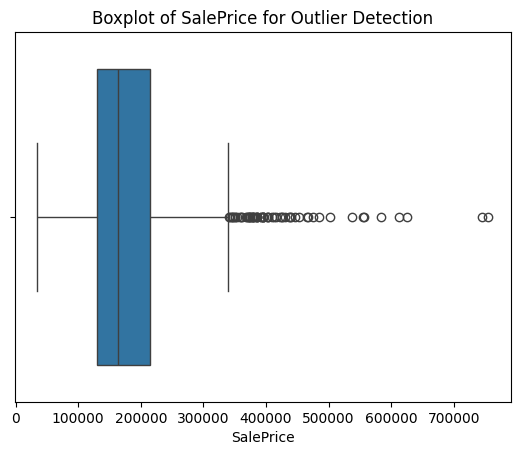

In [7]:
# 7. Outlier Detection
sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot of SalePrice for Outlier Detection')
plt.show()

### 7. Outlier Detection

Outliers in the target variable were analyzed using boxplots to understand extreme values that may affect model performance.

In [6]:
# 6. Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 6. Feature Scaling

Feature scaling was applied using StandardScaler to normalize feature values, especially for algorithms sensitive to scale such as SVR.

In [5]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5. Train-Test Split

The dataset was split into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [4]:
# 4. Feature Selection
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

### 4. Feature Selection

The target variable selected was `SalePrice`, and all other features were used as input variables.

In [3]:
# 3. Handling Categorical Data
df = pd.get_dummies(df, drop_first=True)

### 3. Handling Categorical Data

Categorical variables were converted into numerical form using one-hot encoding to make them suitable for machine learning algorithms.

In [2]:
# 2. Missing Values Handling
print('Missing values before handling:')
display(df.isnull().sum().sort_values(ascending=False).head(20))

# Calculate missing percentages
missing_percentage = df.isnull().sum() / len(df) * 100

# Drop columns with more than 50% missing data
drop_columns = missing_percentage[missing_percentage > 50].index
df = df.drop(columns=drop_columns)
print(f'Dropped columns with >50% missing values: {list(drop_columns)}')

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Fill numerical missing values with the median
for col in numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Filled numerical column {col} with median: {median_val}')

# Fill categorical missing values with the mode
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Filled categorical column {col} with mode: {mode_val}')

print('\nMissing values after handling:')
display(df.isnull().sum().sum())

Missing values before handling:


,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


Dropped columns with >50% missing values: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
Filled numerical column LotFrontage with median: 69.0
Filled numerical column MasVnrArea with median: 0.0
Filled numerical column GarageYrBlt with median: 1980.0
Filled categorical column BsmtQual with mode: TA
Filled categorical column BsmtCond with mode: TA
Filled categorical column BsmtExposure with mode: No
Filled categorical column BsmtFinType1 with mode: Unf
Filled categorical column BsmtFinType2 with mode: Unf
Filled categorical column Electrical with mode: SBrkr
Filled categorical column FireplaceQu with mode: Gd
Filled categorical column GarageType with mode: Attchd
Filled categorical column GarageFinish with mode: Unf
Filled categorical column GarageQual with mode: TA
Filled categorical column GarageCond with mode: TA

Missing values after handling:


/tmp/ipykernel_23258/2152589638.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_23258/2152589638.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

np.int64(0)

### 2. Missing Values Handling

Missing values were handled by removing columns with more than 50% missing data. Numerical features were filled using the median, while categorical features were filled using the mode to preserve data distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/train.csv')

# 1. Dataset Overview
print('Dataset Shape:')
display(df.shape)

print('\nDataset Info:')
display(df.info())

print('\nDataset Description:')
display(df.describe())

Dataset Shape:


(1460, 81)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64 

None


Dataset Description:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1. Dataset Overview

The dataset contains **1460 rows** and **81 columns**. The features include a mix of numerical (e.g., `LotArea`, `OverallQual`) and categorical (e.g., `MSZoning`, `Street`) types. The target variable for this analysis is `SalePrice`, which represents the sale price of a house.